In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

def tdma(a, b, c, d):
    """Solve tridiagonal system with lower a, diagonal b, upper c."""
    n = len(b)
    ac, bc, cc, dc = map(np.array, (a, b, c, d), [float]*4)

    for i in range(1, n):
        m = ac[i] / bc[i-1]
        bc[i] -= m * cc[i-1]
        dc[i] -= m * dc[i-1]

    x = np.zeros(n)
    x[-1] = dc[-1] / bc[-1]

    for i in range(n-2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i+1]) / bc[i]

    return x


def expand_regions(regions):
    """
    regions: list of dictionaries, one per region.
    Each dictionary has:
        Nc, D, Sigma_a, Q, dx
    """
    D, Sa, Q, dx = [], [], [], []

    for reg in regions:
        Nc = reg["Nc"]
        D.extend([reg["D"]] * Nc)
        Sa.extend([reg["Sigma_a"]] * Nc)
        Q.extend([reg["Q"]] * Nc)
        dx.extend([reg["dx"]] * Nc)

    D = np.array(D, dtype=float)
    Sa = np.array(Sa, dtype=float)
    Q = np.array(Q, dtype=float)
    dx = np.array(dx, dtype=float)

    x_edges = np.concatenate(([0.0], np.cumsum(dx)))
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    return x_centers, D, Sa, Q, dx


def solve_slab_diffusion(regions, Jminus_right=0.0):
    """
    Solves:
        -d/dx(D dphi/dx) + Sigma_a phi = Q

    Left BC:
        dphi/dx = 0

    Right BC:
        Jminus = phi/4 + (D/2) dphi/dx
    """
    x, D, Sa, Q, dx = expand_regions(regions)
    N = len(x)

    lower = np.zeros(N)
    diag = np.zeros(N)
    upper = np.zeros(N)
    rhs = Q * dx

    # Interior interface coupling coefficients
    F = np.zeros(N-1)
    for i in range(N-1):
        distance = 0.5 * dx[i] + 0.5 * dx[i+1]
        F[i] = 1.0 / (0.5 * dx[i] / D[i] + 0.5 * dx[i+1] / D[i+1])
        # Equivalent to an interface conductance

    for i in range(N):
        diag[i] += Sa[i] * dx[i]

        if i > 0:
            lower[i] = -F[i-1]
            diag[i] += F[i-1]

        if i < N-1:
            upper[i] = -F[i]
            diag[i] += F[i]

    # Left reflective BC: no extra leakage term needed

    # Right incident partial current BC
    beta = 2.0 * D[-1] / dx[-1]
    alpha = beta / (2.0 * beta + 1.0)
    const = -4.0 * beta * Jminus_right / (2.0 * beta + 1.0)

    diag[-1] += alpha
    rhs[-1] -= const

    A = diags(
        diagonals=[
            lower[1:],   # subdiagonal
            diag,        # main diagonal
            upper[:-1],  # superdiagonal
        ],
        offsets=[-1, 0, 1],
        format="csr"
    )

    phi = spsolve(A, rhs)
    
    return x, phi, Q

def plot_solution(x, phi, Q, title):
    plt.figure(figsize=(8, 5))
    plt.scatter(x, phi, label=r"Flux $\phi$")
    plt.scatter(x, Q, label=r"Source $Q$")
    plt.xlabel("x")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

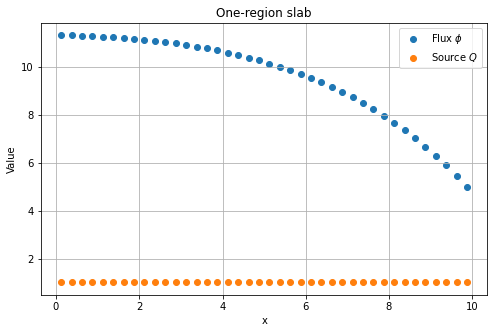

In [6]:
#Example 1: one-region slab
regions_1 = [
    {
        "Nc": 40,
        "D": 1.2,
        "Sigma_a": 0.08,
        "Q": 1.0,
        "dx": 0.25,
    }
]

x1, phi1, Q1 = solve_slab_diffusion(regions_1, Jminus_right=0.0)
plot_solution(x1, phi1, Q1, "One-region slab")

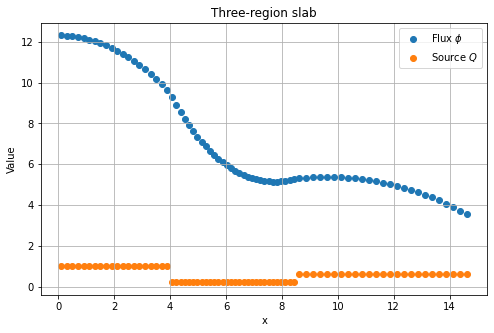

In [7]:
# Example 2: three-region slab
regions_3 = [
    {
        "Nc": 20,
        "D": 1.5,
        "Sigma_a": 0.04,
        "Q": 1.0,
        "dx": 0.20,
    },
    {
        "Nc": 30,
        "D": 0.8,
        "Sigma_a": 0.12,
        "Q": 0.2,
        "dx": 0.15,
    },
    {
        "Nc": 25,
        "D": 2.0,
        "Sigma_a": 0.06,
        "Q": 0.6,
        "dx": 0.25,
    },
]

x3, phi3, Q3 = solve_slab_diffusion(regions_3, Jminus_right=0.05)
plot_solution(x3, phi3, Q3, "Three-region slab")
